# Compromis biais-variance

CSI 4506 - automne 2026

Marcel Turcotte  
Version: août 9, 2026 12h05

# Préambule

## Résumé

Dans cette présentation, nous explorons comment la **complexité du
modèle** influence le **biais**, la **variance**, et la
**généralisation** en examinant le **sous-ajustement** et le
**sur-ajustement** à travers les **courbes d’apprentissage** pour divers
modèles, y compris les modèles linéaires, polynomiaux, basés sur des
arbres, KNN et les réseaux profonds.

## Résultats d’apprentissage

- **Comprendre** comment la complexité du modèle affecte le biais, la
  variance et la généralisation.
- **Analyser** les courbes d’apprentissage pour diagnostiquer le
  sous-ajustement et le sur-ajustement.

# Complexité du modèle

## Justification

L’optimisation de la **performance du modèle** dépend de manière
cruciale de la sélection et du réglage minutieux des
**hyperparamètres**.

Ces hyperparamètres jouent un rôle central dans la régulation de la
**complexité** des modèles d’apprentissage machine.

## Définition

La **complexité du modèle** se réfère à la capacité d’un modèle à
capturer des motifs complexes dans les données.

Elle est déterminée par le **nombre de paramètres** ou la **structure**
du modèle.

## Exploration

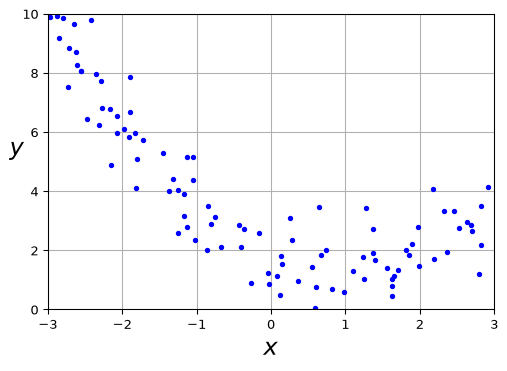

In [1]:
import numpy as np

np.random.seed(42)

X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X ** 2 - X + 2 + np.random.randn(100, 1)

import matplotlib as mpl
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(X, y, "b.")
plt.xlabel("$x$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([-3, 3, 0, 10])
plt.grid(True)
plt.show()

**Attribution** : Géron (2022), Chapitre 4

Dans les expériences d’apprentissage automatique, spécifier le germe du
générateur de nombres aléatoires est crucial pour garantir la
reproductibilité. En fixant un germe, les programmeurs peuvent garantir
que la même séquence de nombres aléatoires sera générée à chaque
exécution de l’expérience. Cette cohérence est vitale pour plusieurs
raisons :

1.  **Reproductibilité** : Elle permet à d’autres programmeurs de
    reproduire l’expérience dans les mêmes conditions exactes,
    facilitant la vérification et la validation des résultats.
2.  **Analyse comparative** : Elle permet une comparaison cohérente
    entre différents modèles ou algorithmes dans les mêmes conditions
    initiales, garantissant que les différences observées sont dues aux
    modèles eux-mêmes plutôt qu’à des variations dans l’initialisation
    aléatoire.
3.  **Débogage** : Elle aide au débogage en fournissant un environnement
    stable où les problèmes peuvent être reproduits et étudiés de
    manière cohérente.

## Régression linéaire

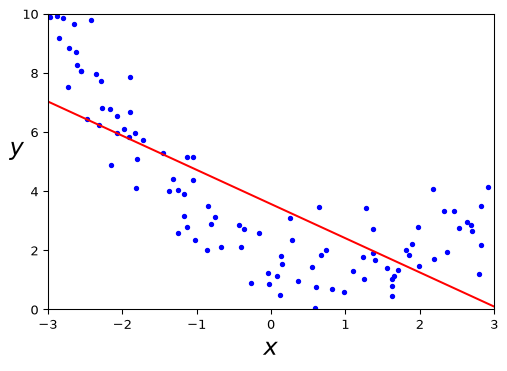

In [2]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)

X_new = np.array([[-3], [3]])
y_pred = lin_reg.predict(X_new)

plt.figure(figsize=(6,4))

plt.plot(X, y, "b.")
plt.plot(X_new, y_pred, "r-")
plt.xlabel("$x$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([-3, 3, 0, 10])
plt.show()

Un **modèle linéaire** représente mal cet ensemble de données.

Ajuster la pente conduit invariablement à un scénario où les résidus
(erreurs) sont minimisés pour certains points de données tout en restant
significatifs pour d’autres.

## Définition

**L’ingénierie des attributs** est le processus de **création**,
**transformation** et **sélection** de variables (attributs) à partir de
données brutes pour améliorer la performance des modèles d’apprentissage
automatique.

Ici, notre objectif est de **créer** de nouveaux attributs à partir de
données brutes.

## Ingénierie de l’apprentissage automatique

![](https://m.media-amazon.com/images/I/51XUfJm64KL._AC_UF350,350_QL50_.jpg)

- [**Machine Learning
  Engineering**](http://www.mlebook.com/wiki/doku.php) par [Andriy
  Burkov](https://www.linkedin.com/in/andriyburkov) (Burkov 2020).
- Couvre la collecte de données, le stockage, le prétraitement,
  l’ingénierie des attributs, le test et le débogage des modèles, le
  déploiement, la retraite et la maintenance.
- De l’auteur de [**Hundred Page Machine Learning
  Book**](https://themlbook.com) (Burkov 2019).
- Disponible sous un modèle “lire d’abord, acheter plus tard”.

## `PolynomialFeatures`

In [3]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

. . .

In [4]:
X[0]

array([-0.75275929])

. . .

In [5]:
X_poly[0]

array([-0.75275929,  0.56664654])

. . .

> 
> **[sklearn.preprocessing.PolynomialFeatures](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html)**
>
> Générez une nouvelle matrice d’attributs constituée de toutes les
> combinaisons polynomiales des attributs avec un degré inférieur ou
> égal au degré spécifié. Par exemple, si un échantillon d’entrée est
> bidimensionnel et de la forme $[a, b]$, les attributs polynomials de
> degré 2 sont $[1, a, b, a^2, ab, b^2]$.

## `PolynomialFeatures`

Étant donné deux attributs $a$ et $b$, `PolynomialFeatures` avec
`degree=3` ajouterait $a^2$, $a^3$, $b^2$, $b^3$, ainsi que $ab$,
$a^2b$, $ab^2$ !

. . .

> **Warning**
>
> `PolynomialFeatures(degree=d)` ajoute $\frac{(D+d)!}{d!D!}$ attributs,
> où $D$ est le nombre initial d’attributs.

De plus, vous avez la possibilité de créer vos propres nouveaux
attributs.

## Régression polynomiale

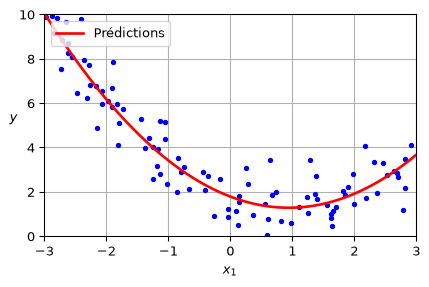

In [6]:
lin_reg = LinearRegression()
lin_reg = lin_reg.fit(X_poly, y)

X_new = np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)

plt.figure(figsize=(5, 3))
plt.plot(X, y, "b.")
plt.plot(X_new, y_new, "r-", linewidth=2, label="Prédictions")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper left")
plt.axis([-3, 3, 0, 10])
plt.grid()
plt.show()

`LinearRegression` sur `PolynomialFeatures`

In [7]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)

## Régression polynomiale

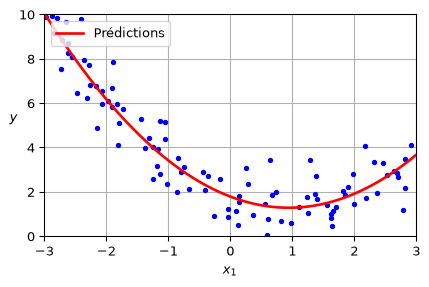

Les données ont été générées selon l’équation suivante, avec l’inclusion
de bruit gaussien.

$$
  y = 0.5 x^2 - 1.0 x + 2.0
$$

Présenté ci-dessous est le modèle appris.

$$
  \hat{y} = 0.56 x^2 + (-1.06) x + 1.78
$$

In [9]:
lin_reg.coef_, lin_reg.intercept_

(array([[-1.06633107,  0.56456263]]), array([1.78134581]))

### 1. **La linéarité concerne les coefficients, pas les entrées brutes**

- La régression logistique est linéaire dans ses **paramètres** (poids).
- La frontière de décision provient de :

$$
\hat{y_i} = \sigma(\theta_0 + \theta_1 z_i^{(1)} + \theta_2 z_i^{(2)} + \dots + \theta_{D'} z_i^{(D')})
$$

où chaque $z_i^{(j)}$ est un attribut.

- Si vous définissez $z_i^{(j)}$ comme une fonction polynomiale des
  variables originales (par exemple $z_i^{(3)} = (x_i^{(1)})^2$), le
  modèle reste *linéaire dans les $z_i^{(j)}$*.

### 2. **PolynomialFeatures ne fait que changer l’espace des attributs**

- `PolynomialFeatures` transforme l’entrée $(x_i^{(1)}, x_i^{(2)})$ en
  un nouveau vecteur :
  $(x_i^{(1)}, x_i^{(2)}, (x_i^{(1)})^2, x_i^{(1)}x_i^{(2)}, (x_i^{(2)})^2, \ldots)$.
- La régression logistique trouve alors une frontière de décision
  linéaire dans cet **espace d’attributs étendu**.
- Lorsque vous le mappez de nouveau à l’espace original
  $(x_i^{(1)}, x_i^{(2)})$, cette surface de décision “linéaire” peut
  apparaître courbée ou sinueuse, mais mathématiquement c’est toujours
  un hyperplan dans l’espace transformé.

**Message clé :**

“La régression logistique trouve toujours une frontière linéaire dans
les attributs que vous lui fournissez. Si vous lui fournissez des
polynômes, la frontière linéaire dans cet espace semble non linéaire
dans l’espace original.”

## Complexité du modèle

``` python
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

plt.figure(figsize=(5, 3))

for style, width, degree in (("r-+", 2, 1), ("b--", 2, 2), ("g-", 1, 300)):
    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = make_pipeline(polybig_features, std_scaler, lin_reg)
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    label = f"{degree} degré{'s' if degree > 1 else ''}"
    plt.plot(X_new, y_newbig, style, label=label, linewidth=width)

plt.plot(X, y, "b.", linewidth=3)
plt.legend(loc="upper left")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([-3, 3, 0, 10])
plt.grid()
plt.show()
```

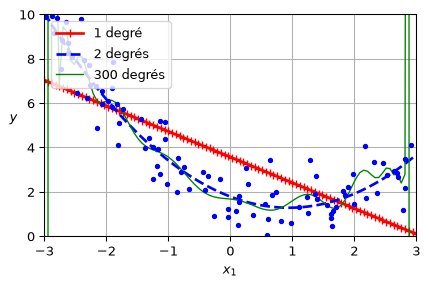

Une **faible valeur de perte** sur l’**ensemble d’entraînement**
n’indique pas nécessairement un modèle “meilleur”.

**Attribution**:
[04_training_linear_models.ipynb](https://github.com/ageron/handson-ml3/blob/main/04_training_linear_models.ipynb)

Dans cet exemple, le modèle de régression linéaire présente une erreur
quadratique moyenne élevée (perte) sur l’ensemble d’entraînement (ligne
rouge). Cela suggère que le modèle commet de nombreuses erreurs même sur
les données d’entraînement.

Inversement, le modèle polynomial avec degré=300 montre une erreur
quadratique moyenne faible (perte) sur l’ensemble d’entraînement (ligne
verte), ce qui implique qu’il commet peu d’erreurs sur les données
d’entraînement.

Cependant, le modèle polynomial de degré=300 est susceptible de mal
performer sur de futures prédictions. La courbe verte dépasse les
limites de l’image sur l’axe des y. Par exemple, pour des valeurs
d’entrée dans la plage de 2 à 3, le modèle prédit des valeurs dépassant
10 (ainsi que des valeurs négatives), alors que les valeurs attendues
devraient se situer dans la plage de 2 à 4.

Cet exemple illustratif peut sembler simpliste puisque les données sont
générées à partir d’une équation quadratique et ne comportent qu’un seul
attribut, ce qui rend la visualisation simple. Cependant, il met en
évidence un point clé pertinent pour des modèles plus complexes, tels
que les réseaux neuronaux profonds. À mesure que le nombre de paramètres
augmente, la capacité du modèle à s’adapter aux données d’entraînement
augmente également, ce qui peut conduire à un surapprentissage si cela
n’est pas correctement géré.

## Sous- et sur- ajustement

- **Sous-ajustement (*underfitting*):**
  - Votre modèle est **trop simple** (ici, linéaire).
  - Attributs non informatifs.
  - **Mauvaise** performance sur les données d’**entraînement** et de
    **test**.
- **Sur-ajustement (*overfitting*):**
  - Votre modèle est **trop complexe** (arbre de décision haut, réseaux
    neuronaux profonds et larges, etc.).
  - **Trop d’attributs** étant donné le nombre d’exemples disponibles.
  - **Excellente** performance sur l’**ensemble d’entraînement**, mais
    **mauvaise** performance sur l’ensemble de test.

Un modèle est dit en **sous-ajustement** lorsqu’il échoue à capturer la
structure sous-jacente des données, il performe mal tant sur l’ensemble
d’entraînement que sur les données de test non vues. Voici les
principales façons dont cela peut se produire :

### **Capacité du modèle trop faible**

- **Classe d’hypothèse trop simple** : par ex., ajuster une ligne droite
  (régression linéaire) à des données avec un motif quadratique.
- **Architecture peu profonde** : utiliser un perceptron monocouche pour
  une tâche de classification fortement non linéaire.
- **Trop peu d’attributs** : ne pas fournir suffisamment de variables
  descriptives au modèle pour capturer le signal.

### **Trop de régularisation**

- **Pénalité L2 (ridge) ou L1 (lasso) excessive** réduit presque à zéro
  les coefficients.
- **Taux de dropout trop élevé** dans les réseaux neuronaux.
- **Arrêt prématuré** avant que le modèle n’apprenne les motifs.

### **Problèmes d’optimisation**

- **Taux d’apprentissage trop petit** : le modèle apprend à peine,
  bloqué avec une perte élevée.
- **Taux d’apprentissage trop grand** : l’optimiseur oscille, ne
  converge jamais correctement.
- **Trop peu d’époques/itérations d’entraînement** : le modèle ne reçoit
  pas suffisamment de mises à jour pour s’adapter aux données.
- **Mauvaise initialisation** (surtout dans les problèmes non convexes
  comme les réseaux profonds) peut entraver la convergence.

### **Causes liées aux données**

- **Le bruit des étiquettes domine le signal** : si l’ensemble de
  données est très bruyant, même un bon modèle semble sous-ajuster.
- **Volume de données insuffisant** : le modèle ne peut pas bien
  généraliser car l’ensemble d’entraînement ne capture pas la véritable
  structure.
- **Problèmes de mise à l’échelle des attributs** : par ex., régression
  logistique ou réseaux neuronaux entraînés sur des attributs brutes,
  non mises à l’échelle, mauvaise convergence et ajustement.
- **Mauvaise ingénierie des attributs** : termes d’interaction
  manquants, termes polynomiaux, embeddings, etc.

### **Incompatibilités algorithmiques**

- **Mauvaise fonction de perte** : par ex., utiliser MSE pour une
  classification fortement déséquilibrée au lieu de la perte
  logarithmique.
- **Choix de modèle incompatible** : par ex., k-NN avec `k` trop grand,
  prédit presque toujours la classe majoritaire.
- **Hypothèse de biais trop forte** : par ex., Naive Bayes supposant
  l’indépendance des attributs alors qu’elle est fortement violée.

**Résumé :**

Le sous-ajustement se produit lorsque le modèle est **trop contraint**
(faible capacité, trop de régularisation, trop peu d’entraînement) ou
lorsque le **processus d’entraînement échoue** (problèmes
d’optimisation/données). On le remarque généralement lorsque la **perte
d’entraînement reste élevée** même après un long entraînement.

Un modèle **sur-ajuste** lorsqu’il apprend non seulement la structure
sous-jacente des données d’entraînement mais aussi le **bruit et les
idiosyncrasies**, ce qui conduit à une mauvaise généralisation sur les
données non vues. Voici les principales façons dont cela peut se
produire :

### **Capacité du modèle trop élevée**

- Modèle trop flexible (par ex., réseau neuronal très profond sur un
  petit ensemble de données).
- Trop d’attributs par rapport au nombre d’échantillons → haute
  variance.
- Ajouter des attributs polynomiaux de haut degré sans suffisamment de
  données.

### **Trop peu de régularisation**

- Pénalité L1/L2 faible ou inexistante permet aux poids de devenir très
  grands.
- Taux de dropout trop faible ou désactivé.

### **Entraînement trop long**

- Le modèle continue de minimiser la perte d’entraînement bien au-delà
  du point où la perte de validation atteint son minimum.
- Pas d’arrêt précoce → mémorisation du bruit/des valeurs aberrantes.

### **Problèmes de données**

- L’ensemble d’entraînement est trop petit, le modèle mémorise au lieu
  de généraliser.
- Bruit d’étiquettes élevé, le modèle s’ajuste aux erreurs.
- Fuite d’informations de test dans l’entraînement (par ex.,
  prétraitement, mise à l’échelle ou construction d’attributs
  inadéquats).

### **Incompatibilité d’évaluation**

- Hyperparamètres ajustés directement sur l’ensemble de test, le modèle
  s’adapte à cet ensemble de test plutôt qu’à la distribution
  sous-jacente.
- Les plis de validation croisée ne sont pas stratifiés, signaux de
  généralisation trompeurs.

### **Choix algorithmiques**

- k-NN avec `k=1` (mémorise les points d’entraînement).
- Arbre de décision sans profondeur maximale ni élagage.
- Réseau neuronal avec trop de paramètres par rapport à la taille du jeu
  de données.

**Résumé :**

Le sur-ajustement se produit lorsque le modèle a **trop de liberté**,
**trop peu de contraintes**, ou **s’entraîne trop longtemps** sur un
ensemble de données limité/bruyant. On le reconnaît lorsque la **perte
d’entraînement est très basse mais la perte de validation/test est
beaucoup plus élevée**.

## Courbes d’apprentissage

- Une façon d’**évaluer nos modèles** est de visualiser les **courbes
  d’apprentissage** :
  - Une **courbe d’apprentissage** montre la performance de notre
    modèle, ici en utilisant la RMSE, à la fois sur le **jeu
    d’entraînement** et le **jeu de test**.
  - Plusieurs **mesures** sont obtenues en entraînant le modèle de
    manière répétée sur des **sous-ensembles** de données **de plus en
    plus grands**.

**Voir** :
[sklearn.model_selection.learning_curve](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.learning_curve.html).

## Courbe d’apprentissage – Sous-ajustement

``` python
from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores = learning_curve(
    LinearRegression(), X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_root_mean_squared_error")

train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.figure(figsize=(6, 4))  # code supplémentaire – non nécessaire, juste pour le formatage
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="test")

# code supplémentaire – embellit
plt.xlabel("Taille du jeu d'entraînement")
plt.ylabel("RMSE")
plt.grid()
plt.legend(loc="upper right")
plt.axis([0, 80, 0, 2.5])
plt.show()
```

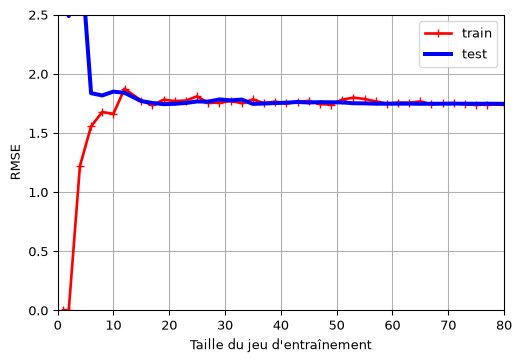

- Polynôme avec **degré=1**.

- Performance **médiocre** sur les données de **formation** et de
  **test**.

**Code source**:
[04_training_linear_models.ipynb](https://github.com/ageron/handson-ml3/blob/main/04_training_linear_models.ipynb).

Ce graphique illustre la courbe d’apprentissage pour un modèle de
régression linéaire appliqué à des données générées à partir d’une
équation quadratique, qui sert d’exemple continu.

L’axe horizontal représente la taille du jeu d’entraînement.
Initialement, le modèle de régression linéaire est entraîné sur un très
petit jeu de données, composé d’un ou de quelques exemples, et l’erreur
quadratique moyenne (RMSE) est tracée pour les ensembles de formation et
de test. La taille du jeu d’entraînement est ensuite augmentée
progressivement, un nouveau modèle est entraîné, et la performance est
enregistrée. Cette procédure continue jusqu’à ce que l’ensemble du jeu
de données soit utilisé.

Les observations clés du graphique incluent :

- Avec un ou deux exemples seulement, le modèle s’ajuste parfaitement au
  jeu d’entraînement, résultant en un faible RMSE pour les données
  d’entraînement.

- À mesure que la taille du jeu d’entraînement augmente, le modèle a du
  mal à s’ajuster aux données d’entraînement en raison de la nature
  quadratique du processus de génération de données. Par conséquent, le
  RMSE pour le jeu d’entraînement augmente et se stabilise à un niveau
  plus élevé.

- Pour les petits jeux d’entraînement, le modèle fonctionne mal sur le
  jeu de test en raison d’une généralisation inadéquate, ce qui entraîne
  un RMSE élevé.

- À mesure que la taille du jeu d’entraînement augmente, la performance
  sur le jeu de test s’améliore, indiquée par une diminution du RMSE,
  jusqu’à atteindre un point où de nouvelles augmentations de la taille
  du jeu d’entraînement n’apportent pas d’améliorations significatives.

Ces courbes d’apprentissage sont indicatives d’un modèle qui
sous-ajuste. Les courbes de RMSE pour les ensembles de formation et de
test se stabilisent à des valeurs relativement élevées et restent
proches l’une de l’autre, comme le note Géron (2022).

## Courbe d’apprentissage – Surapprentissage

``` python
from sklearn.pipeline import make_pipeline

polynomial_regression = make_pipeline(
    PolynomialFeatures(degree=14, include_bias=False),
    LinearRegression())

train_sizes, train_scores, valid_scores = learning_curve(
    polynomial_regression, X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_root_mean_squared_error")
# code supplémentaire – génère et enregistre la Figure 4–16

train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="test")
plt.legend(loc="upper right")
plt.xlabel("Taille de l'ensemble d'entraînement")
plt.ylabel("RMSE")
plt.grid()
plt.axis([0, 80, 0, 2.5])
plt.show()
```

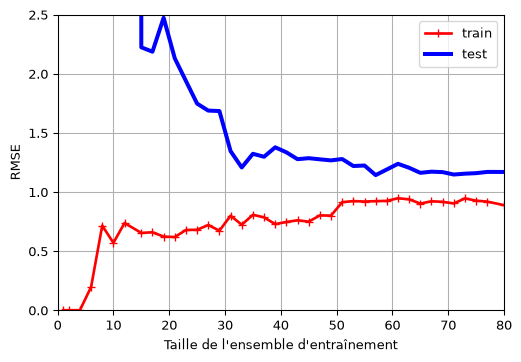

- Polynôme avec **degré=14**.

- Performance **excellente** sur l’**ensemble d’entraînement**, mais
  performance **médiocre** sur l’**ensemble de test**.

- Pour un ensemble d’entraînement allant jusqu’à 14 points de données,
  le polynôme s’ajuste parfaitement aux données d’entraînement,
  entraînant un RMSE de zéro.

- L’erreur sur les **données d’entraînement** dans ce cas est
  significativement plus basse.

- Un écart notable entre les deux courbes indique que le modèle
  fonctionne nettement mieux sur les données d’entraînement par rapport
  aux données de test.

## Surapprentissage - Réseaux profonds

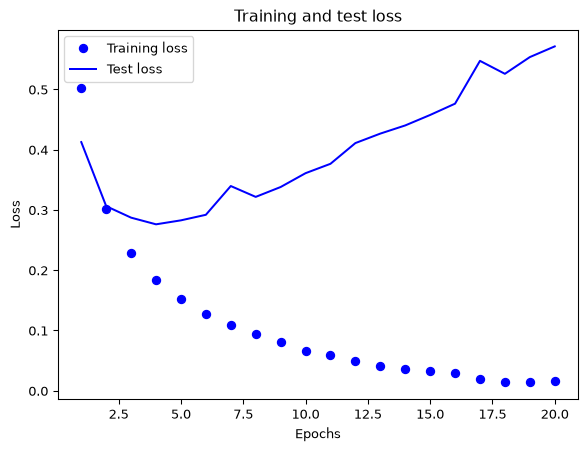

Exemple tiré de Chollet (2017) Chapitre 3
([chapter04_getting-started-with-neural-networks.ipynb](https://github.com/fchollet/deep-learning-with-python-notebooks/blob/master/chapter04_getting-started-with-neural-networks.ipynb),
ipynb de l’édition 2021).

Les réseaux de neurones seront abordés en détail plus tard dans notre
cours. Le graphique présenté ici illustre la variation de la fonction de
perte au fur et à mesure qu’un modèle d’apprentissage profond
s’entraîne.

Cet exemple utilise le [jeu de données de classification de sentiments
des critiques de films IMDB disponible dans
Keras](https://keras.io/api/datasets/imdb/). Le jeu de données comprend
25 000 critiques de films provenant d’[IMDB](https://www.imdb.com),
chacune étant étiquetée avec un sentiment (positif ou négatif).

Le modèle se compose de trois couches denses de tailles 16, 16 et 1,
respectivement. Il inclut un total de 160 305 paramètres entraînables.

Le réseau est entraîné en utilisant la descente de gradient stochastique
par mini-lots avec une taille de lot de 512. L’axe horizontal représente
le nombre d’époques, où chaque époque indique que le modèle a vu
l’ensemble d’entraînement une fois. Au cours de chaque époque,
l’algorithme de descente de gradient stochastique met à jour les
paramètres du modèle de manière itérative en utilisant des mini-lots de
512 exemples.

J’ai choisi cet exemple pour illustrer qu’un réseau de neurones avec une
capacité suffisante (nombre de paramètres) peut minimiser les erreurs
d’entraînement presque à zéro, car réduire l’erreur d’entraînement est
l’objectif principal de l’optimisation. Cependant, le graphique démontre
clairement qu’au-delà d’un certain point, les motifs appris deviennent
spécifiques au jeu d’entraînement plutôt que des principes généraux. La
généralisation, plutôt que la simple mémorisation, est l’objectif ultime
de l’apprentissage automatique.

Le surapprentissage se produit lorsqu’un modèle apprend les détails et
le bruit dans les données d’entraînement à un point tel que cela impacte
négativement la performance du modèle sur de nouvelles données. Cela
peut entraîner une frontière de décision qui s’adapte trop étroitement
aux données d’entraînement, capturant du bruit et des détails non
pertinents plutôt que des motifs généraux.

## Surapprentissage - Réseau profond

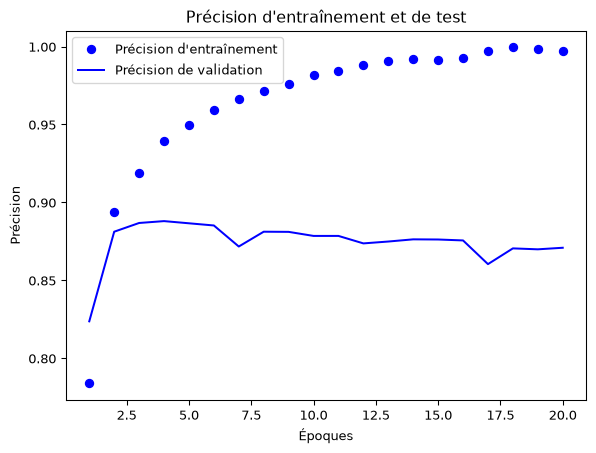

Ce graphique illustre de manière similaire la variation de l’exactitude
pour les ensembles d’entraînement et de test au fur et à mesure que le
modèle subit l’entraînement.

# Compromis biais-variance

## Biais

- **Biais** fait référence à l’erreur introduite en approximant un
  problème du monde réel, qui peut être complexe, en utilisant un modèle
  simplifié.

- Il représente la **différence** entre la **prédiction moyenne** du
  modèle et le **résultat vrai**.

- Un **biais élevé** peut amener un algorithme à **manquer des motifs
  importants**, conduisant à un **sous-ajustement**.

## Biais

$$
 \text{Biais}(\hat{f}) = \mathbb{E}[\hat{f}(x)] - f(x)
$$ où :

- $\hat{f}(x)$ est la prédiction faite par le modèle,
- $f(x)$ est la fonction vraie,
- $\mathbb{E}[\hat{f}(x)]$ est la prédiction attendue sur différents
  ensembles de données.

## Variance

- **Variance** mesure la **sensibilité du modèle aux fluctuations dans
  les données d’entraînement**.

- Une **variance élevée** indique que le modèle **capture le bruit**
  comme s’il s’agissait d’un vrai motif, conduisant à un
  **surdéajustement**.

- Elle reflète combien **les prédictions du modèle varieraient** si
  **différentes données d’entraînement** étaient utilisées.

## Variance

$$
 \text{Variance}(\hat{f}) = \mathbb{E}[(\hat{f}(x) - \mathbb{E}[\hat{f}(x)])^2]
$$

où :

- $\hat{f}(x)$ est la prédiction faite par le modèle,
- $\mathbb{E}[\hat{f}(x)]$ est la prédiction attendue sur différents
  ensembles de données.

## Remarques

- **L’apprentissage statistique** fait des hypothèses sur le modèle, la
  distribution des données et le bruit pour dériver analytiquement les
  valeurs attendues.

- Dans les applications pratiques, des techniques empiriques comme la
  **validation croisée** et le **bootstrapping** sont utilisées pour
  estimer le biais et la variance.

## Compromis biais-variance

$$
  \text{Erreur} = \text{Biais}^2 + \text{Variance} + \text{Erreur Irréductible}
  $$

- La sélection de modèle vise à **minimiser le biais**, qui provient de
  modèles *trop simplistes*, et la **variance**, qui résulte de modèles
  *trop complexes sujets au surapprentissage*.

- Idéalement, avec **des données infinies**, à la fois le **biais** et
  la **variance** pourraient être **réduits à zéro**.

- Cependant, en pratique, **les données sont généralement bruitées**, et
  une certaine erreur irréductible persiste en raison de facteurs non
  pris en compte au-delà de la portée du modèle.

Visez une complexité de modèle qui capture les motifs essentiels sans
tomber dans le surapprentissage.

## Compromis biais-variance

![](https://upload.wikimedia.org/wikipedia/commons/thumb/9/9f/Bias_and_variance_contributing_to_total_error.svg/2560px-Bias_and_variance_contributing_to_total_error.svg.png)

**Attribution** : [Bigbossfarin, CC0, via Wikimedia
Commons](https://commons.wikimedia.org/wiki/File:Bias_and_variance_contributing_to_total_error.svg)

## Compromis biais-variance

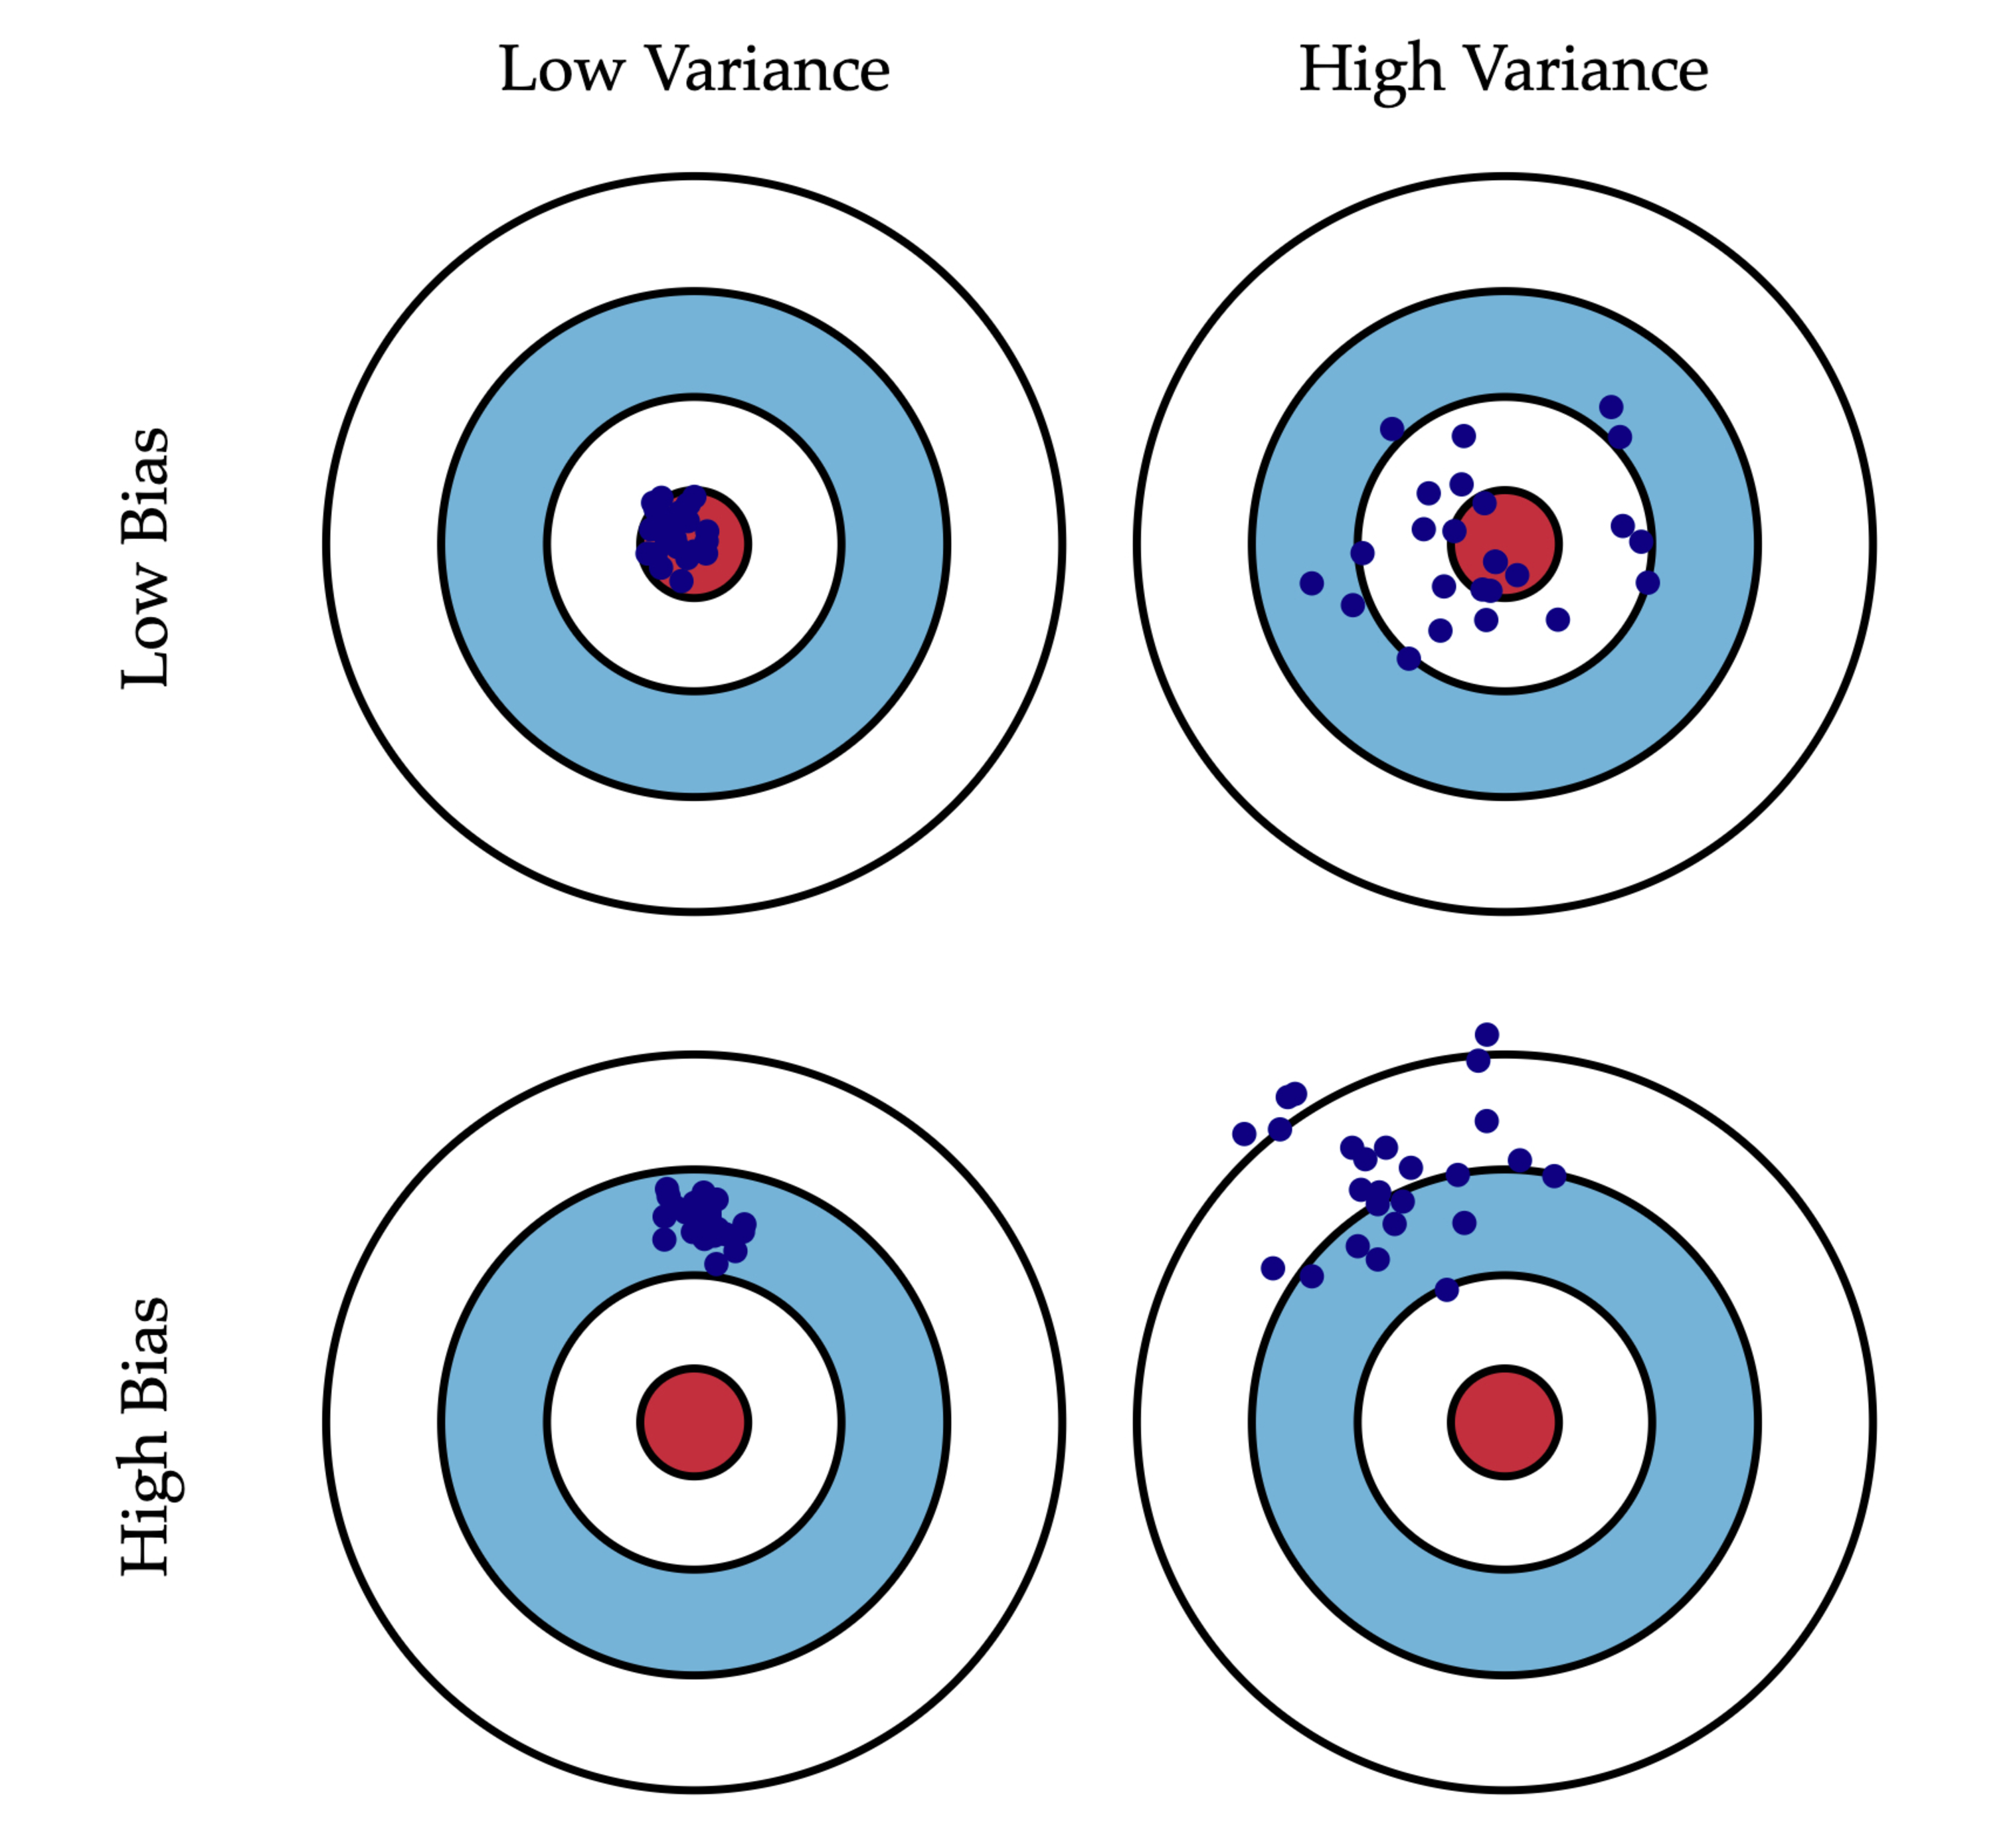

**Attribution :** [Understanding the Bias-Variance
Tradeoff](https://scott.fortmann-roe.com/docs/BiasVariance.html) par
Scott Fortmann-Roe, juin 2012.

## Biais élevé, faible variance

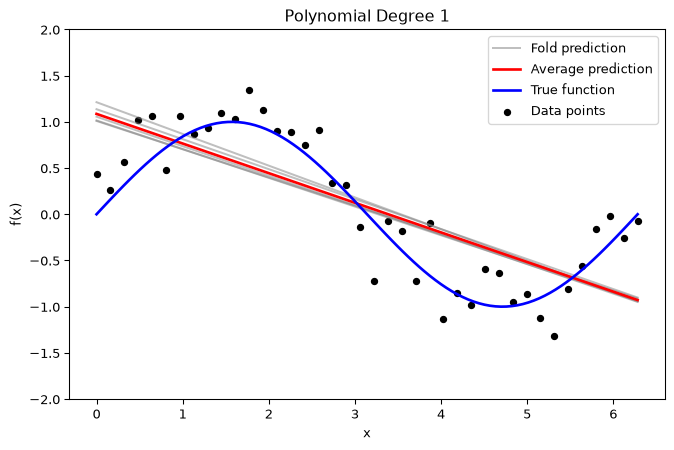

In [19]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

def true_function(x):
    return np.sin(x)

def plot_fold_predictions(degree, X, y, X_grid, y_true_grid, n_splits=5, random_state=42):
    """
    For a given polynomial degree, perform KFold cross-validation,
    plot the individual fold predictions along with the average prediction 
    and the true function (with y-axis limited to [-2, 2]),
    and return predictions and errors.
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_predictions = []  # To store predictions on the evaluation grid for each fold
    fold_errors = []       # To store test errors for each fold

    for train_index, test_index in kf.split(X):
        poly = PolynomialFeatures(degree=degree)
        X_train_poly = poly.fit_transform(X[train_index])
        X_test_poly = poly.transform(X[test_index])
        X_grid_poly = poly.transform(X_grid)
        
        model = LinearRegression()
        model.fit(X_train_poly, y[train_index])
        
        # Predictions on the dense grid for bias-variance analysis
        y_pred_grid = model.predict(X_grid_poly)
        fold_predictions.append(y_pred_grid)
        
        # Test error on held-out data
        y_pred_test = model.predict(X_test_poly)
        fold_errors.append(mean_squared_error(y[test_index], y_pred_test))
    
    fold_predictions = np.array(fold_predictions)
    avg_prediction = np.mean(fold_predictions, axis=0)
    
    # Plot individual fold predictions with y-axis limited to [-2, 2]
    plt.figure(figsize=(8, 5))
    for i in range(n_splits):
        plt.plot(X_grid, fold_predictions[i], color='gray', alpha=0.5, 
                 label='Fold prediction' if i == 0 else "")
    plt.plot(X_grid, avg_prediction, color='red', linewidth=2, label='Average prediction')
    plt.plot(X_grid, y_true_grid, color='blue', linewidth=2, label='True function')
    plt.scatter(X, y, color='black', s=20, label='Data points')
    plt.ylim(-2, 2)
    plt.title(f'Polynomial Degree {degree}')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.legend()
    plt.show()
    
    return fold_predictions, avg_prediction, fold_errors

# --- Data Generation with Increased Noise and Reduced Sample Size ---
np.random.seed(0)
n_samples = 40  # Reduced sample size increases model sensitivity to training data
X = np.linspace(0, 2 * np.pi, n_samples).reshape(-1, 1)
noise_std = 0.25  # Increased noise level amplifies prediction variability
y = true_function(X).ravel() + np.random.normal(0, noise_std, size=n_samples)

# Create a dense evaluation grid and compute the true function values
X_grid = np.linspace(0, 2 * np.pi, 100).reshape(-1, 1)
y_true_grid = true_function(X_grid).ravel()

# --- Plot Individual Fold Predictions for Selected Degrees ---
_ = plot_fold_predictions(1, X, y, X_grid, y_true_grid, n_splits=5)

- **Biais élevé** : Le modèle manque de complexité et, par conséquent,
  ne parvient pas à capturer les motifs sous-jacents dans les données,
  ce qui entraîne une erreur moyenne élevée.

- **Faible variance** : Le modèle montre une insensibilité aux
  variations dans l’ensemble de données, ce qui se traduit par une
  faible variance.

## Biais faible, variance élevée

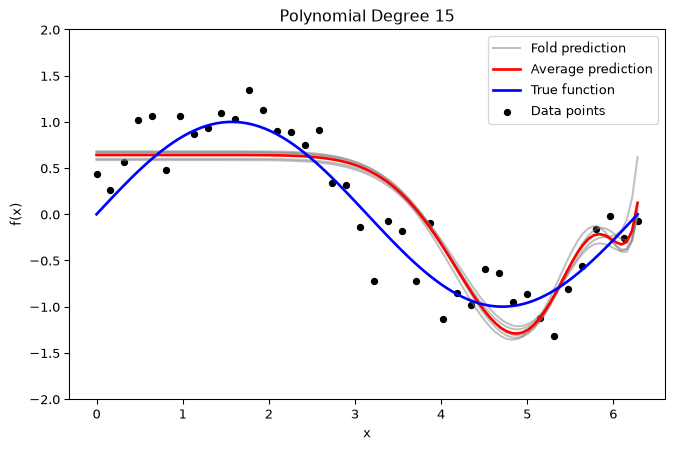

In [20]:
_ = plot_fold_predictions(15, X, y, X_grid, y_true_grid, n_splits=5)

## Parfait

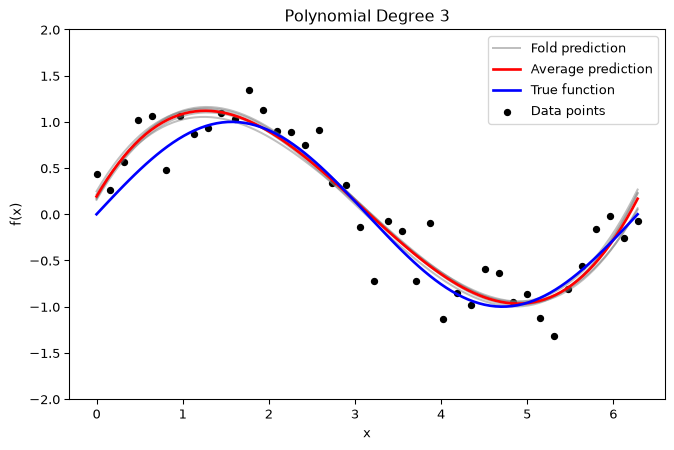

In [21]:
_ = plot_fold_predictions(3, X, y, X_grid, y_true_grid, n_splits=5)

## Biais, variance et erreur de validation

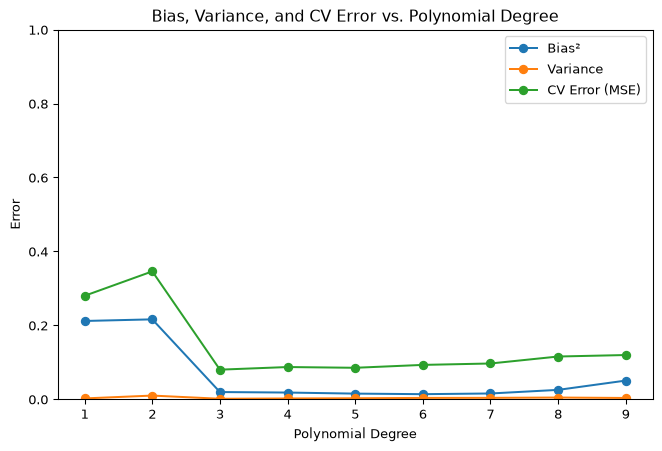

In [22]:
# --- Compute Bias², Variance, and CV Error Across Degrees 1 to 10 ---
degrees = range(1, 10)
bias_list = []
variance_list = []
cv_error_list = []

for degree in degrees:
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_predictions = []
    fold_errors = []
    
    for train_index, test_index in kf.split(X):
        poly = PolynomialFeatures(degree=degree)
        X_train_poly = poly.fit_transform(X[train_index])
        X_test_poly = poly.transform(X[test_index])
        X_grid_poly = poly.transform(X_grid)
        
        model = LinearRegression()
        model.fit(X_train_poly, y[train_index])
        
        y_pred_grid = model.predict(X_grid_poly)
        fold_predictions.append(y_pred_grid)
        
        y_pred_test = model.predict(X_test_poly)
        fold_errors.append(mean_squared_error(y[test_index], y_pred_test))
    
    fold_predictions = np.array(fold_predictions)
    mean_prediction = np.mean(fold_predictions, axis=0)
    
    # Bias²: Average squared difference between the average prediction and the true function
    bias_sq = np.mean((mean_prediction - y_true_grid)**2)
    # Variance: Average variance of the predictions across the evaluation grid
    variance = np.mean(np.var(fold_predictions, axis=0))
    # CV Error: Mean of the MSE on held-out test sets
    cv_error = np.mean(fold_errors)
    
    bias_list.append(bias_sq)
    variance_list.append(variance)
    cv_error_list.append(cv_error)

# --- Plot Bias², Variance, and CV Error vs. Polynomial Degree ---
plt.figure(figsize=(8, 5))
plt.plot(degrees, bias_list, marker='o', label='Bias²')
plt.plot(degrees, variance_list, marker='o', label='Variance')
plt.plot(degrees, cv_error_list, marker='o', label='CV Error (MSE)')
plt.title('Bias, Variance, and CV Error vs. Polynomial Degree')
plt.xlabel('Polynomial Degree')
plt.ylabel('Error')
plt.ylim(0, 1)
plt.legend()
plt.show()

## Abre de décision

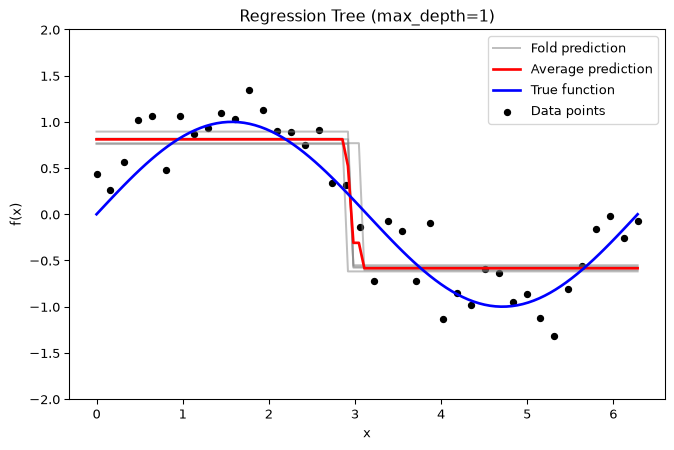

In [23]:
from sklearn.tree import DecisionTreeRegressor

def plot_tree_fold_predictions(max_depth, X, y, X_grid, y_true_grid, n_splits=5, random_state=42):
    """
    For a given tree max_depth, perform KFold cross-validation with a DecisionTreeRegressor,
    plot the individual fold predictions along with the average prediction and the true function.
    The y-axis is limited to [-2, 2] for clarity.
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_predictions = []  # Store predictions on the evaluation grid for each fold
    fold_errors = []       # Store test errors for each fold

    for train_index, test_index in kf.split(X):
        X_train = X[train_index]
        X_test = X[test_index]
        
        model = DecisionTreeRegressor(max_depth=max_depth, random_state=random_state)
        model.fit(X_train, y[train_index])
        
        # Prediction on a dense evaluation grid
        y_pred_grid = model.predict(X_grid)
        fold_predictions.append(y_pred_grid)
        
        # Test error on held-out data
        y_pred_test = model.predict(X_test)
        fold_errors.append(mean_squared_error(y[test_index], y_pred_test))
    
    fold_predictions = np.array(fold_predictions)
    avg_prediction = np.mean(fold_predictions, axis=0)
    
    plt.figure(figsize=(8, 5))
    for i in range(n_splits):
        plt.plot(X_grid, fold_predictions[i], color='gray', alpha=0.5,
                 label='Fold prediction' if i == 0 else "")
    plt.plot(X_grid, avg_prediction, color='red', linewidth=2, label='Average prediction')
    plt.plot(X_grid, y_true_grid, color='blue', linewidth=2, label='True function')
    plt.scatter(X, y, color='black', s=20, label='Data points')
    plt.ylim(-2, 2)
    plt.title(f'Regression Tree (max_depth={max_depth})')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.legend()
    plt.show()
    
    return fold_predictions, avg_prediction, fold_errors

# --- Plot Individual Fold Predictions for Selected Tree Depths ---
_ = plot_tree_fold_predictions(1, X, y, X_grid, y_true_grid, n_splits=5)

## Arbre de décision

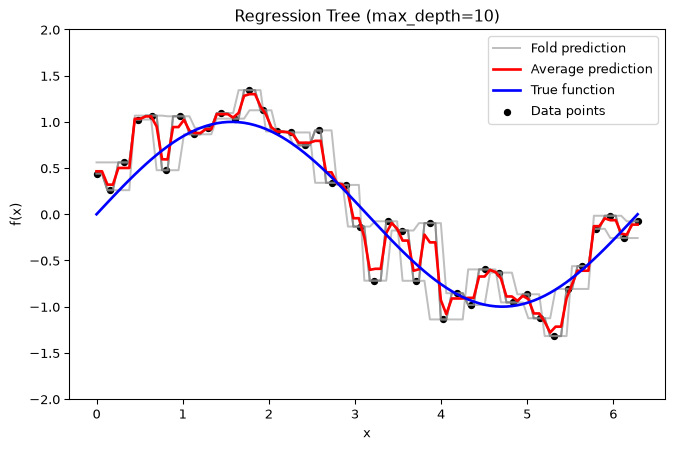

In [24]:
_ = plot_tree_fold_predictions(10, X, y, X_grid, y_true_grid, n_splits=5)

## Arbre de décision

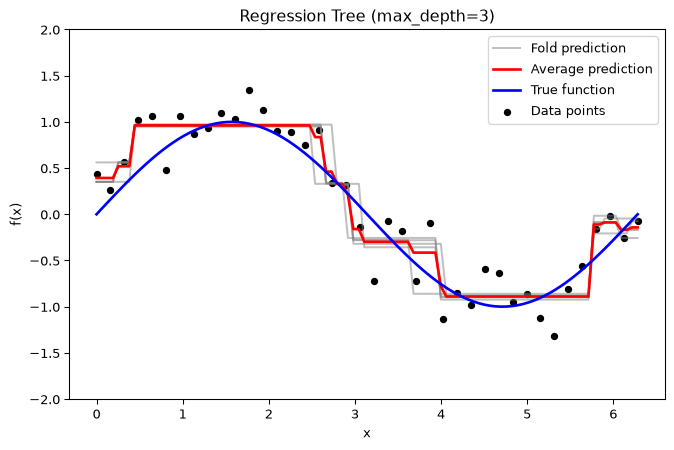

In [25]:
_ = plot_tree_fold_predictions(3, X, y, X_grid, y_true_grid, n_splits=5)

## Biais, variance et erreur de validation

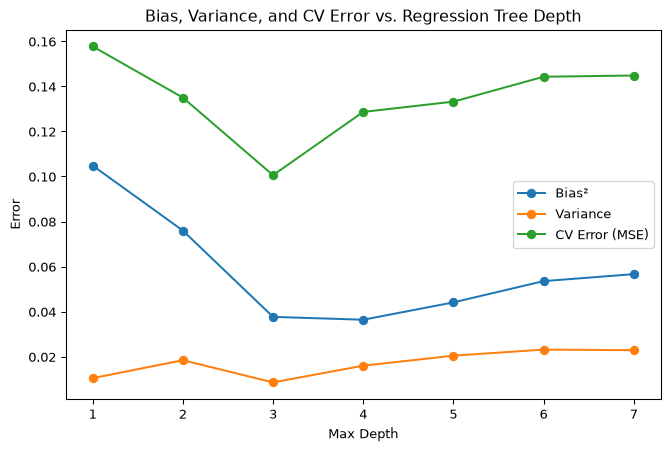

In [26]:
# --- Compute Bias², Variance, and CV Error vs. Tree Depth ---
max_depths = range(1, 8)
bias_list = []
variance_list = []
cv_error_list = []

for depth in max_depths:
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_predictions = []
    fold_errors = []
    
    for train_index, test_index in kf.split(X):
        X_train = X[train_index]
        X_test = X[test_index]
        
        model = DecisionTreeRegressor(max_depth=depth, random_state=42)
        model.fit(X_train, y[train_index])
        
        y_pred_grid = model.predict(X_grid)
        fold_predictions.append(y_pred_grid)
        
        y_pred_test = model.predict(X_test)
        fold_errors.append(mean_squared_error(y[test_index], y_pred_test))
    
    fold_predictions = np.array(fold_predictions)
    mean_prediction = np.mean(fold_predictions, axis=0)
    
    # Bias²: Mean squared difference between the average prediction and the true function
    bias_sq = np.mean((mean_prediction - y_true_grid)**2)
    # Variance: Average variance of predictions across the evaluation grid
    variance = np.mean(np.var(fold_predictions, axis=0))
    # CV Error: Average test error over folds
    cv_error = np.mean(fold_errors)
    
    bias_list.append(bias_sq)
    variance_list.append(variance)
    cv_error_list.append(cv_error)

plt.figure(figsize=(8, 5))
plt.plot(max_depths, bias_list, marker='o', label='Bias²')
plt.plot(max_depths, variance_list, marker='o', label='Variance')
plt.plot(max_depths, cv_error_list, marker='o', label='CV Error (MSE)')
plt.title('Bias, Variance, and CV Error vs. Regression Tree Depth')
plt.xlabel('Max Depth')
plt.ylabel('Error')
# plt.ylim(0, 1)
plt.legend()
plt.show()

## KNN Regression

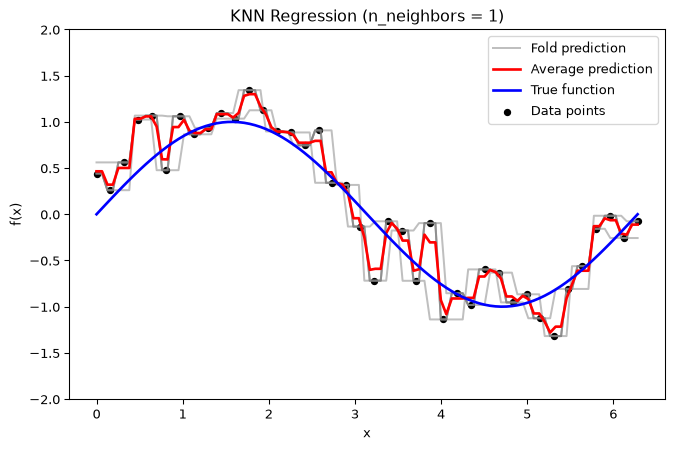

In [27]:
from sklearn.neighbors import KNeighborsRegressor

def plot_knn_fold_predictions(n_neighbors, X, y, X_grid, y_true_grid, n_splits=5, random_state=42):
    """
    For a given number of neighbors, perform KFold cross-validation using KNeighborsRegressor,
    plot the predictions from each fold along with the average prediction and the true function.
    The y-axis is limited to [-2, 2] for clarity.
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_predictions = []  # Store predictions on the evaluation grid for each fold
    fold_errors = []       # Store test errors for each fold

    for train_index, test_index in kf.split(X):
        X_train = X[train_index]
        X_test = X[test_index]
        
        model = KNeighborsRegressor(n_neighbors=n_neighbors)
        model.fit(X_train, y[train_index])
        
        # Prediction on a dense evaluation grid for bias-variance analysis
        y_pred_grid = model.predict(X_grid)
        fold_predictions.append(y_pred_grid)
        
        # Test error on held-out data
        y_pred_test = model.predict(X_test)
        fold_errors.append(mean_squared_error(y[test_index], y_pred_test))
    
    fold_predictions = np.array(fold_predictions)
    avg_prediction = np.mean(fold_predictions, axis=0)
    
    # Plot individual fold predictions
    plt.figure(figsize=(8, 5))
    for i in range(n_splits):
        plt.plot(X_grid, fold_predictions[i], color='gray', alpha=0.5,
                 label='Fold prediction' if i == 0 else "")
    plt.plot(X_grid, avg_prediction, color='red', linewidth=2, label='Average prediction')
    plt.plot(X_grid, y_true_grid, color='blue', linewidth=2, label='True function')
    plt.scatter(X, y, color='black', s=20, label='Data points')
    plt.ylim(-2, 2)
    plt.title(f'KNN Regression (n_neighbors = {n_neighbors})')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.legend()
    plt.show()
    
    return fold_predictions, avg_prediction, fold_errors

# --- Plot Individual Fold Predictions for Selected Values of k ---
_ = plot_knn_fold_predictions(1, X, y, X_grid, y_true_grid, n_splits=5)

## KNN Regression

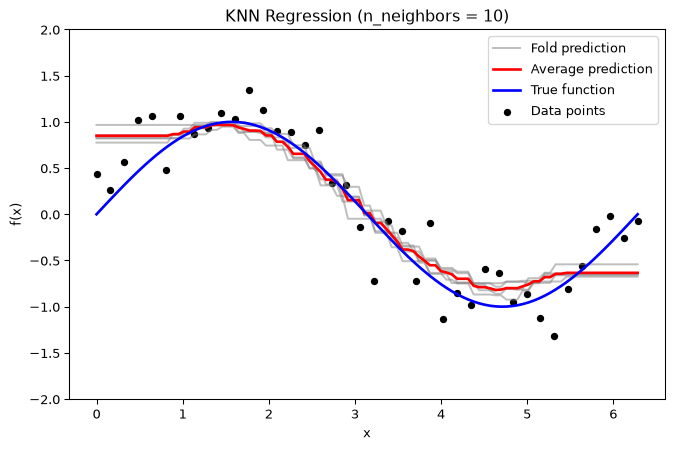

In [28]:
_ = plot_knn_fold_predictions(10, X, y, X_grid, y_true_grid, n_splits=5)

## KNN Regression

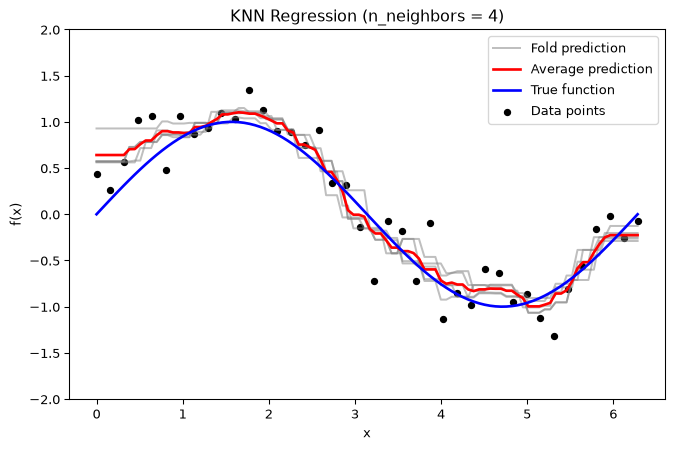

In [29]:
_ = plot_knn_fold_predictions(4, X, y, X_grid, y_true_grid, n_splits=5)

## Biais, variance et erreur de validation

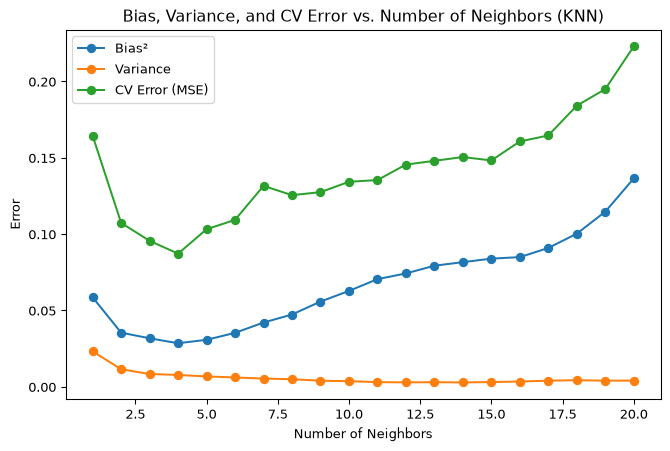

In [30]:
# --- Compute Bias², Variance, and CV Error vs. Number of Neighbors ---
neighbors_range = range(1, 21)  # Vary k from 1 to 20
bias_list = []
variance_list = []
cv_error_list = []

for k in neighbors_range:
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_predictions = []
    fold_errors = []
    
    for train_index, test_index in kf.split(X):
        X_train = X[train_index]
        X_test = X[test_index]
        
        model = KNeighborsRegressor(n_neighbors=k)
        model.fit(X_train, y[train_index])
        
        y_pred_grid = model.predict(X_grid)
        fold_predictions.append(y_pred_grid)
        
        y_pred_test = model.predict(X_test)
        fold_errors.append(mean_squared_error(y[test_index], y_pred_test))
    
    fold_predictions = np.array(fold_predictions)
    mean_prediction = np.mean(fold_predictions, axis=0)
    
    # Bias²: Mean squared difference between the average prediction and the true function
    bias_sq = np.mean((mean_prediction - y_true_grid)**2)
    # Variance: Average variance of predictions across the evaluation grid
    variance = np.mean(np.var(fold_predictions, axis=0))
    # CV Error: Average MSE on the held-out test sets
    cv_error = np.mean(fold_errors)
    
    bias_list.append(bias_sq)
    variance_list.append(variance)
    cv_error_list.append(cv_error)

# --- Plot Bias², Variance, and CV Error vs. Number of Neighbors ---
plt.figure(figsize=(8, 5))
plt.plot(neighbors_range, bias_list, marker='o', label='Bias²')
plt.plot(neighbors_range, variance_list, marker='o', label='Variance')
plt.plot(neighbors_range, cv_error_list, marker='o', label='CV Error (MSE)')
plt.title('Bias, Variance, and CV Error vs. Number of Neighbors (KNN)')
plt.xlabel('Number of Neighbors')
plt.ylabel('Error')
# plt.ylim(0, 1)
plt.legend()
plt.show()

Comment expliquez-vous que le biais$^2$ augmente avec la valeur de $k$ ?

Au début, cela peut sembler contre-intuitif, mais c’est une conséquence
directe de la manière dont fonctionne le KNN.

Avec un $k$ très bas (par exemple, $k = 1$), le modèle fait des
prédictions basées sur le voisin le plus proche, capturant presque tous
les détails des données d’entraînement—cela entraîne un biais faible
mais une variance élevée car les prédictions sont très sensibles au
bruit.

En revanche, un $k$ plus élevé force le régresseur à faire la moyenne
sur de nombreux voisins, ce qui lisse les prédictions. Cela donne un
modèle plus simple, moins flexible, qui pourrait ne pas capturer les
nuances locales (biais élevé) mais est moins sensible aux fluctuations
dans l’ensemble d’entraînement (variance faible).

# Prologue

## Résumé

- Évaluation de la complexité des modèles et de son impact sur la
  performance.
- Illustration du sous-ajustement, du sur-ajustement, et du compromis
  biais-variance.
- Démonstration des courbes d’apprentissage et de la validation croisée
  à travers divers modèles (linéaire, polynomial, arbre, KNN, réseaux
  profonds).

## Prochain cours

- Ingénierie de l’apprentissage automatique

## Références

Burkov, A. 2020. *Machine Learning Engineering*. True Positive
Incorporated. <https://books.google.ca/books?id=HeXizQEACAAJ>.

Burkov, Andriy. 2019. *The Hundred-Page Machine Learning Book*. Andriy
Burkov.

Chollet, François. 2017. *Deep learning with Python*. Manning
Publications.

Géron, Aurélien. 2022. *Hands-on Machine Learning with Scikit-Learn,
Keras, and TensorFlow*. 3ᵉ éd. O’Reilly Media, Inc.

Russell, Stuart, et Peter Norvig. 2020. *Artificial Intelligence: A
Modern Approach*. 4ᵉ éd. Pearson. <http://aima.cs.berkeley.edu/>.

# Annexe : Ingénierie des attributs et classification

## Données

Génération d’un jeu de données comprenant un cercle intérieur (classe 1)
et un anneau extérieur (classe 0).

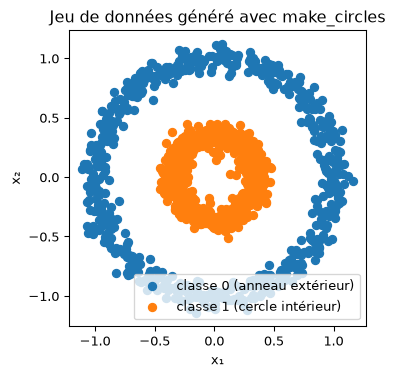

In [31]:
# Générer et tracer le jeu de données "cercles"
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

# Générer des données synthétiques
X, y = make_circles(n_samples=1200, factor=0.35, noise=0.06, random_state=42)

# Séparer les coordonnées pour le tracé
x1, x2 = X[:, 0], X[:, 1]

# Tracer les deux classes
plt.figure(figsize=(4, 4))
plt.scatter(x1[y==0], x2[y==0], color="C0", label="classe 0 (anneau extérieur)")
plt.scatter(x1[y==1], x2[y==1], color="C1", label="classe 1 (cercle intérieur)")
plt.xlabel("x₁")
plt.ylabel("x₂")
plt.title("Jeu de données généré avec make_circles")
plt.axis("equal") # assure que les cercles apparaissent ronds
plt.legend()
plt.show()

Il est clair que ce jeu de données n’est pas linéairement séparable en
$(x_1, x_2)$ !

## Ingénierie des attributs

Lors de l’utilisation d’un classificateur linéaire comme
[`LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html),
il n’est pas possible de dériver des paramètres permettant une
classification précise des exemples donnés.

Nous pourrions incorporer deux attributs supplémentaires, $x_1^2$ et
$x_2^2$. Cela permet la classification des exemples en utilisant la
régression logistique. Cependant, l’espace des attributs devient à
quatre dimensions, compliquant la visualisation directe.

## Ingénierie des attributs (suite)

Dans ce cahier, nous introduisons un seul attribut spécifiquement conçu
pour faciliter la visualisation. $$
r = x_1^2 + x_2^2,
$$ **(r)** représente la **distance au carré depuis l’origine** —
essentiellement le **rayon au carré** en coordonnées polaires.

## Intuition

- Chaque point dans le plan 2-D original a des coordonnées $(x_1, x_2)$.
- Si vous exprimez ces mêmes coordonnées en forme polaire, vous avez

$$
  x_1 = r^{1/2} \cos\theta, \quad x_2 = r^{1/2} \sin\theta,
$$ ou plus conventionnellement,
$r_{\text{polar}} = \sqrt{x_1^2 + x_2^2}$.

- Ici, nous définissons $r = x_1^2 + x_2^2$, c’est-à-dire le **carré**
  de ce rayon.

Utiliser $r$ au lieu de $\sqrt{r}$ garde la correspondance
différentiable et évite les racines carrées dans le modèle.

## Pourquoi c’est utile

Dans l’ensemble de données “cercle vs. anneau” :

- Les points du **cercle intérieur** sont proches de l’origine, petit
  $r$.
- Les points de l’**anneau extérieur** sont plus éloignés, grand $r$.

Ainsi, le problème qui est **non linéaire** en $(x_1, x_2)$ devient
**linéairement séparable** en $r$ :

$$
\text{intérieur si } r < r^*, \quad \text{extérieur si } r > r^*.
$$

Donc, $r$ est un **attribut encodant la distance radiale**, permettant à
un modèle linéaire comme la régression logistique de séparer les classes
avec un seul seuil en 1-D.

## Vue 3D

In [32]:
import numpy as np
from sklearn.datasets import make_circles
from sklearn.linear_model import LogisticRegression
import plotly.graph_objects as go

# --- notre nouvelle caractéristique ---
r = x1**2 + x2**2

# --- ajuster la régression logistique sur r uniquement et obtenir le plan de seuil ---

clf = LogisticRegression().fit(r.reshape(-1,1), y)
w = float(clf.coef_[0][0]); b = float(clf.intercept_[0])
r_thresh = -b / w

# --- nuage de points 3D de (x1, x2, r) ---

scatter = go.Scatter3d(
    x=x1, y=x2, z=r,
    mode="markers",
    marker=dict(size=3, color=y, colorscale="Viridis", showscale=False),
    hovertemplate="x1=%{x:.3f}<br>x2=%{y:.3f}<br>r=%{z:.3f}<extra></extra>",
    name="points"
)

# --- plan horizontal z = r_thresh ---

gx = np.linspace(x1.min()-0.2, x1.max()+0.2, 50)
gy = np.linspace(x2.min()-0.2, x2.max()+0.2, 50)
GX, GY = np.meshgrid(gx, gy)
GZ = np.full_like(GX, r_thresh)

plane = go.Surface(
    x=GX, y=GY, z=GZ,
    opacity=0.35, showscale=False,
    hoverinfo="skip",
    name="plan p=0.5"
)

fig = go.Figure(data=[plane, scatter])
fig.update_scenes(
    xaxis_title="x₁", yaxis_title="x₂", zaxis_title="r = x₁² + x₂²",
    aspectmode="cube",
    camera=dict(eye=dict(x=1.6, y=1.6, z=0.9))
)
fig.update_layout(margin=dict(l=0,r=0,b=0,t=30), title=f"Plan de décision à r* ≈ {r_thresh:.3f}")
fig

## Malheureusement, les objets graphiques de plotly ne peuvent être visualisés qu'en HTML, pas en PDF.
## TODO : Explorer https://plotly.com/python/static-image-export/, cela pourrait être une solution.

$(x_1,x_2,r)$ avec $r=x_1^2+x_2^2$

## Séparabilité linéaire en 1D (espace-r)

En comparant deux modèles, `clf_r` utilise un seul attribut,
$r=x_1^2+x_2^2$, tandis que `quad` inclut des caractéristiques
polynomiales de degré 2.

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

r = (x1**2 + x2**2).reshape(-1, 1)

# Modèles
clf_r = LogisticRegression().fit(r, y)

quad = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("logreg", LogisticRegression(max_iter=1000))
]).fit(X, y)

# Seuil r* (p=0.5) pour le modèle basé uniquement sur r

w = float(clf_r.coef_[0][0]); b = float(clf_r.intercept_[0])
r_thresh = -b / w if abs(w) > 1e-12 else None

## Visualisation

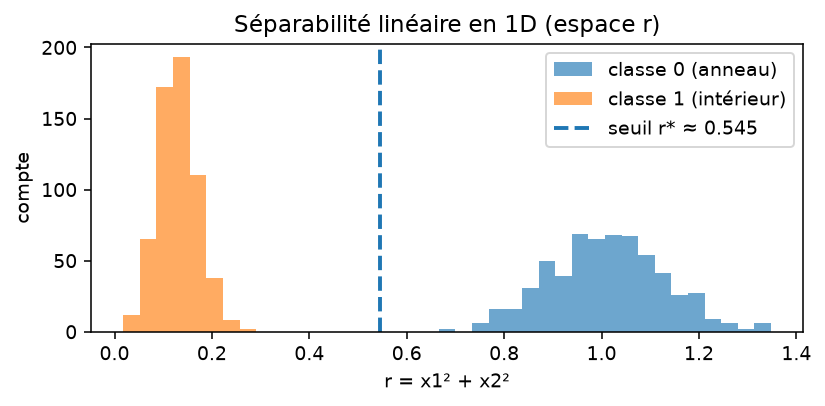

In [34]:
plt.figure(figsize=(6,3), dpi=140)
bins = np.linspace(r.min(), r.max(), 40)
plt.hist(r[y==0], bins=bins, alpha=0.65, label="classe 0 (anneau)")
plt.hist(r[y==1], bins=bins, alpha=0.65, label="classe 1 (intérieur)")
if r_thresh is not None:
    plt.axvline(r_thresh, linestyle="--", linewidth=2, label=f"seuil r* ≈ {r_thresh:.3f}")
plt.xlabel("r = x1² + x2²"); plt.ylabel("compte")
plt.title("Séparabilité linéaire en 1D (espace r)")
plt.legend(); plt.tight_layout(); plt.show()

## Espace r en 1D

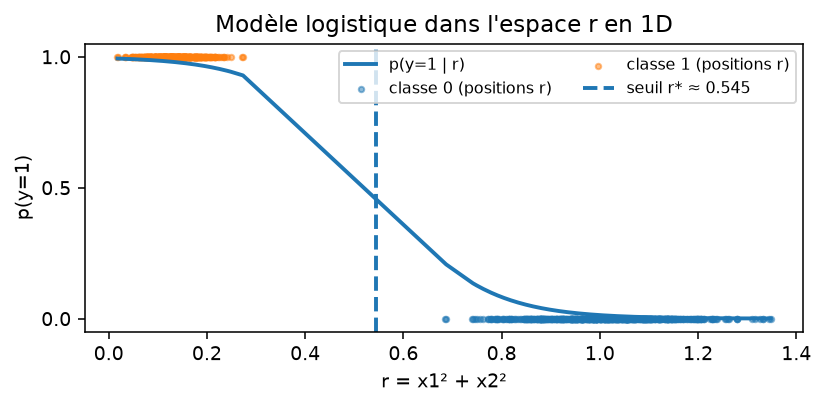

In [35]:
order = np.argsort(r.ravel())
r_sorted = r.ravel()[order]
p_sorted = clf_r.predict_proba(r_sorted.reshape(-1,1))[:,1]

plt.figure(figsize=(6,3), dpi=140)
plt.plot(r_sorted, p_sorted, linewidth=2, label="p(y=1 | r)")
plt.scatter(r[y==0], np.zeros_like(r[y==0]), s=8, alpha=0.5, label="classe 0 (positions r)")
plt.scatter(r[y==1], np.ones_like(r[y==1]), s=8, alpha=0.5, label="classe 1 (positions r)")
if r_thresh is not None:
    plt.axvline(r_thresh, linestyle="--", linewidth=2, label=f"seuil r* ≈ {r_thresh:.3f}")
plt.yticks([0, 0.5, 1]); plt.ylim(-0.05, 1.05)
plt.xlabel("r = x1² + x2²"); plt.ylabel("p(y=1)")
plt.title("Modèle logistique dans l'espace r en 1D")
plt.legend(loc="best", ncol=2, fontsize=8)
plt.tight_layout(); plt.show()

## r = x1² + x2²

Utilise `clf_r.predict_proba` pour tracer la frontière de décision.

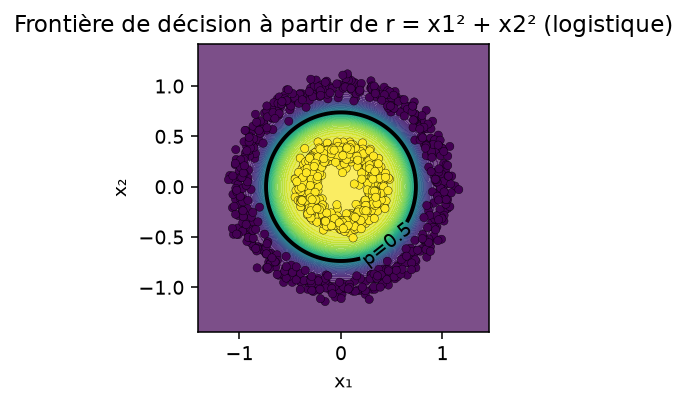

In [36]:
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-0.3, X[:,0].max()+0.3, 400),
    np.linspace(X[:,1].min()-0.3, X[:,1].max()+0.3, 400)
)
grid = np.c_[xx.ravel(), yy.ravel()]
r_grid = (grid[:,0]**2 + grid[:,1]**2).reshape(-1,1)
p_r = clf_r.predict_proba(r_grid)[:, 1].reshape(xx.shape)

plt.figure(figsize=(3,3), dpi=140)
cf = plt.contourf(xx, yy, p_r, levels=50, alpha=0.7)
cs = plt.contour(xx, yy, p_r, levels=[0.5], linewidths=2, colors="k")
plt.scatter(X[:,0], X[:,1], c=y, s=18, edgecolor="k", linewidth=0.2)
plt.clabel(cs, fmt={0.5:"p=0.5"})
plt.title("Frontière de décision à partir de r = x1² + x2² (logistique)")
plt.xlabel("x₁"); plt.ylabel("x₂"); plt.tight_layout(); plt.show()

## Caractéristiques quadratiques

Utilise `quad.predict_proba` pour tracer la frontière de décision.

(En effet, les deux modèles produisent le même résultat.)

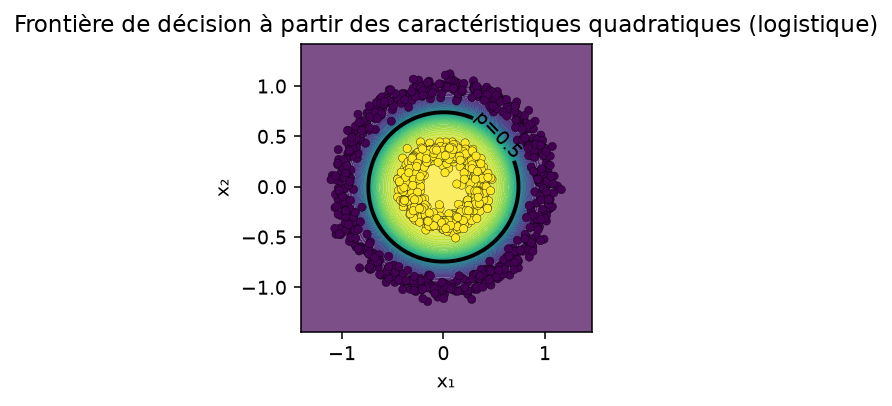

In [37]:
p_quad = quad.predict_proba(grid)[:, 1].reshape(xx.shape)

plt.figure(figsize=(3,3), dpi=140)
cf = plt.contourf(xx, yy, p_quad, levels=50, alpha=0.7)
cs2 = plt.contour(xx, yy, p_quad, levels=[0.5], linewidths=2, colors="k")
plt.scatter(X[:,0], X[:,1], c=y, s=18, edgecolor="k", linewidth=0.2)
plt.clabel(cs2, fmt={0.5:"p=0.5"})
plt.title("Frontière de décision à partir des caractéristiques quadratiques (logistique)")
plt.xlabel("x₁"); plt.ylabel("x₂"); plt.tight_layout(); plt.show()

------------------------------------------------------------------------

Marcel **Turcotte**

<Marcel.Turcotte@uOttawa.ca>

École de **science informatique** et de génie électrique (**SI**GE)

Université d’Ottawa